# Récupération de phase — Algorithme de Gerchberg–Saxton



## Objectif

L’objectif de ce notebook est de reconstruire la phase d’un champ optique à partir de mesures d’intensité uniquement, en utilisant l’algorithme de Gerchberg–Saxton.

On cherche à analyser :
- la convergence de l’algorithme
- ses limites
- l’influence des discontinuités de phase
---

## Contexte physique

En optique, un champ électromagnétique est une quantité complexe :

$$
E(r) = A(r)e^{i\phi(r)}
$$

où $A(r)$ est l’amplitude et $\phi(r)$ la phase.


Les capteurs (CCD, etc.) ne mesurent que l’**intensité** :

$$
I(r) = |E(r)|^2
$$

ce qui entraîne une **perte d’information sur la phase**.
 
---

## Algorithme de Gerchberg–Saxton

L’idée est d’itérer entre le plan objet et le plan de Fourier, en imposant à chaque étape les contraintes connues :

1. **Initialisation**  
   $x_0 = |f| e^{i\phi_0}$ (phase initiale arbitraire)

2. **Transformée de Fourier directe**  
   $X_k = \mathcal{F}(x_k)$

3. **Contrainte en Fourier**  
   Remplacer le module par le module mesuré :  
   $X'_k = |F| e^{i\psi_k}$

4. **Transformée de Fourier inverse**  
   $x'_k = \mathcal{F}^{-1}(X'_k)$

5. **Contrainte objet**  
   Restaurer l’amplitude connue :  
   $x_{k+1} = |f| e^{i\phi_k}$

6. **Répéter** jusqu’à convergence.

## 1. Imports et configuration

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Paramètres globaux de visualisation
plt.rcParams.update({'figure.dpi': 100,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
})


## 2. Construction de l'objet et de la phase réelle

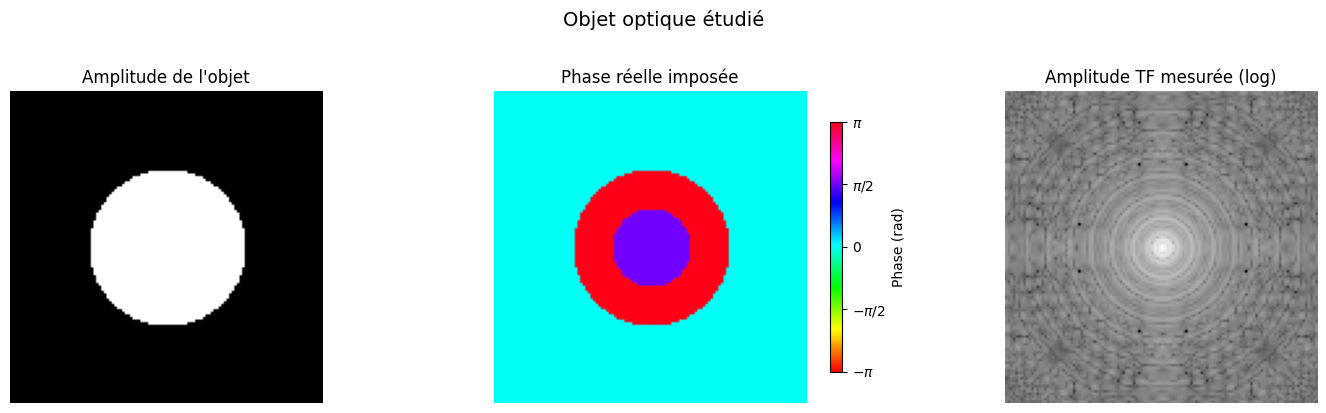

Grille : 120×120 pixels | Rayon ext. : 30 px | Rayon int. : 15 px


In [3]:
# ─── Paramètres de la grille ───
N = 120          # taille de la grille (N x N pixels)
rayon_ext = 30   # rayon extérieur du disque
rayon_int = 15   # rayon intérieur (centre)

# Grille centrée en (0, 0)
x = np.arange(N) - N / 2
y = np.arange(N) - N / 2
X, Y = np.meshgrid(x, y)
R = np.sqrt(X**2 + Y**2)

# ─── Amplitude de l'objet ───
# Disque binaire : amplitude 1 dans le cercle, 0 en dehors
figure = np.zeros((N, N))
figure[R < rayon_ext] = 1.0

# ─── Phase réelle imposée ───
# Anneau extérieur : phase π
# Centre (r < rayon_int) : phase π/2
# Fond : phase nulle (non pertinente car amplitude = 0)
phase_reelle = np.zeros((N, N))
phase_reelle[R < rayon_ext] = np.pi
phase_reelle[R < rayon_int] = np.pi / 2

# Champ complexe initial (objet avec phase réelle)
Lum_phasee = figure * np.exp(1j * phase_reelle)

# ─── Visualisation de l'objet ───
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Amplitude
axes[0].imshow(figure, cmap='gray')
axes[0].set_title("Amplitude de l'objet")
axes[0].axis('off')

# Phase
im1 = axes[1].imshow(np.angle(Lum_phasee), cmap='hsv', vmin=-np.pi, vmax=np.pi)
axes[1].set_title('Phase réelle imposée')
axes[1].axis('off')

cbar1 = plt.colorbar(im1, ax=axes[1], shrink=0.8)
cbar1.set_ticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
cbar1.set_ticklabels([r'$-\pi$', r'$-\pi/2$', '0', r'$\pi/2$', r'$\pi$'])
cbar1.set_label('Phase (rad)')

# Transformée de Fourier
TF_reelle = np.fft.fftshift(np.fft.fft2(Lum_phasee))
TF_mesure = np.abs(TF_reelle)

axes[2].imshow(np.log10(TF_mesure + 1e-9), cmap='gray')
axes[2].set_title('Amplitude TF mesurée (log)')
axes[2].axis('off')

plt.suptitle('Objet optique étudié', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(f'Grille : {N}×{N} pixels | Rayon ext. : {rayon_ext} px | Rayon int. : {rayon_int} px')

## 3. Implémentation de l'algorithme de Gerchberg–Saxton

On implémente ici l’algorithme itératif permettant de reconstruire la phase à partir des contraintes dans les plans objet et de Fourier.

In [4]:
def gerchberg_saxton(amplitude_objet, TF_mesure, n_iter=500, phase_init='zeros'):
    """
    Algorithme de Gerchberg–Saxton pour la récupération de phase.
    """

    N = amplitude_objet.shape[0]

    # Initialisation
    if phase_init == 'random':
        phi0 = 2 * np.pi * np.random.rand(N, N)
    else:
        phi0 = np.zeros((N, N))

    champ = amplitude_objet * np.exp(1j * phi0)

    erreurs_fourier = []
    erreurs_objet = []

    for _ in range(n_iter):
        G = np.fft.fftshift(np.fft.fft2(champ))

        E_fourier = np.sqrt(np.sum((np.abs(G) - TF_mesure)**2) / N**2)
        erreurs_fourier.append(E_fourier)

        G2 = TF_mesure * np.exp(1j * np.angle(G))

        g = np.fft.ifft2(np.fft.ifftshift(G2))

        E_objet = np.sqrt(np.sum((np.abs(g) - amplitude_objet)**2))
        erreurs_objet.append(E_objet)

        champ = amplitude_objet * np.exp(1j * np.angle(g))

    return champ, erreurs_fourier, erreurs_objet

## 4. Fonctions de visualisation

Ces fonctions permettent de comparer la phase réelle et estimée, ainsi que d’observer la convergence de l’algorithme.

In [5]:
def afficher_resultats(phase_reelle_2D, champ_estime, erreurs_fourier, erreurs_objet, titre=''):
    phase_estimee_2D = np.angle(champ_estime)
    N = phase_reelle_2D.shape[0]

    fig = plt.figure(figsize=(18, 4))
    fig.suptitle(titre, fontsize=13, y=1.01)
    gs = gridspec.GridSpec(1, 4, figure=fig)

    ax0 = fig.add_subplot(gs[0])
    im0 = ax0.imshow(phase_reelle_2D, cmap='hsv', vmin=-np.pi, vmax=np.pi)
    ax0.set_title('Phase réelle')
    ax0.axis('off')
    _colorbar_phase(fig, im0, ax0)

    ax1 = fig.add_subplot(gs[1])
    im1 = ax1.imshow(phase_estimee_2D, cmap='hsv', vmin=-np.pi, vmax=np.pi)
    ax1.set_title('Phase estimée (G–S)')
    ax1.axis('off')
    _colorbar_phase(fig, im1, ax1)

    ax2 = fig.add_subplot(gs[2])
    ax2.semilogy(erreurs_fourier, label='Plan de Fourier')
    ax2.semilogy(erreurs_objet, label='Plan objet')
    ax2.set_title('Convergence')
    ax2.legend()
    ax2.grid(True)

    ax3 = fig.add_subplot(gs[3])
    cx = np.linspace(-0.5, 0.5, N)
    row = N // 2
    ax3.plot(cx, phase_reelle_2D[row, :], 'b.', label='Réelle')
    ax3.plot(cx, phase_estimee_2D[row, :], 'r.', label='Estimée')
    ax3.set_title('Coupe centrale')
    ax3.legend()

    plt.tight_layout()
    plt.show()


def _colorbar_phase(fig, im, ax):
    cbar = fig.colorbar(im, ax=ax, shrink=0.8)
    cbar.set_ticks([-np.pi, 0, np.pi])
    cbar.set_ticklabels([r'$-\pi$', '0', r'$\pi$'])

## 5. Expériences : phases discontinues

On teste différentes configurations de phase pour analyser le comportement de l’algorithme.

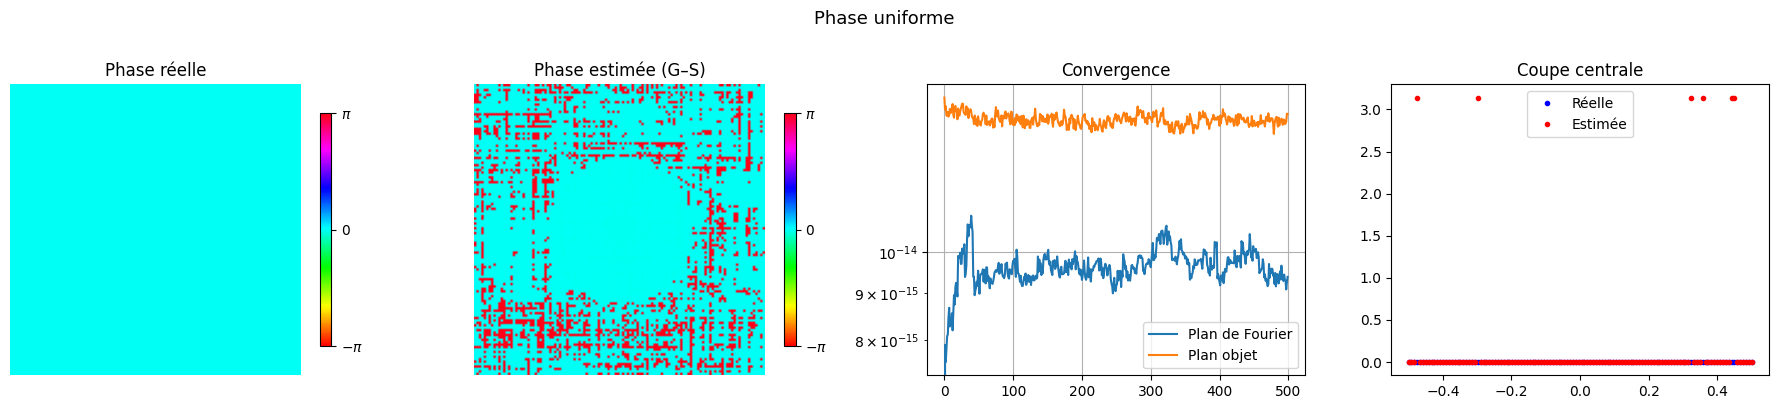

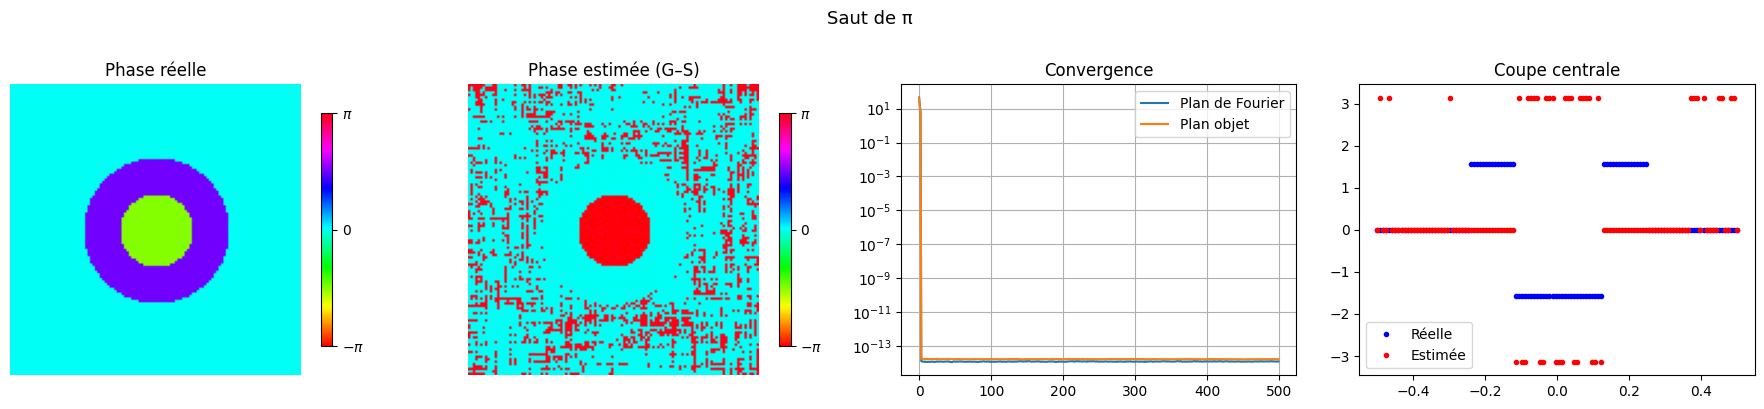

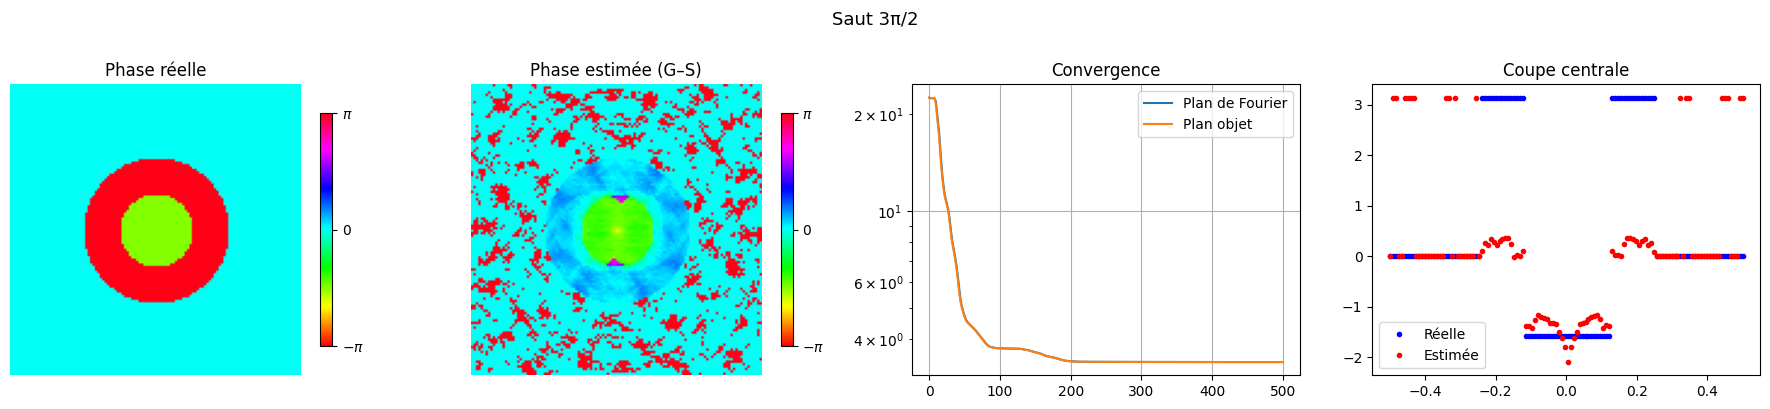

In [6]:
def construire_objet(N, rayon_ext, rayon_int, phase_anneau, phase_centre):
    x = np.arange(N) - N / 2
    y = np.arange(N) - N / 2
    X, Y = np.meshgrid(x, y)
    R = np.sqrt(X**2 + Y**2)

    amplitude = np.zeros((N, N))
    amplitude[R < rayon_ext] = 1.0

    phase = np.zeros((N, N))
    phase[R < rayon_ext] = phase_anneau
    phase[R < rayon_int] = phase_centre

    return amplitude, amplitude * np.exp(1j * phase)


cas = [
    (0, 0, 'Phase uniforme'),
    (np.pi/2, -np.pi/2, 'Saut de π'),
    (np.pi, -np.pi/2, 'Saut 3π/2'),
]

for pa, pc, label in cas:
    amp, champ = construire_objet(N, rayon_ext, rayon_int, pa, pc)
    TF_mes = np.abs(np.fft.fftshift(np.fft.fft2(champ)))

    champ_estime, E_f, E_o = gerchberg_saxton(amp, TF_mes)
    afficher_resultats(np.angle(champ), champ_estime, E_f, E_o, titre=label)

## 6. Expérience : rampe de phase

On ajoute une rampe de phase correspondant à une onde plane inclinée.

In [ ]:
def construire_objet_rampe(N, rayon_ext, rayon_int, pa, pc, kx=0, ky=0):
    x = np.arange(N) - N / 2
    y = np.arange(N) - N / 2
    X, Y = np.meshgrid(x, y)
    R = np.sqrt(X**2 + Y**2)

    amplitude = np.zeros((N, N))
    amplitude[R < rayon_ext] = 1.0

    phase = np.zeros((N, N))
    phase[R < rayon_ext] = pa
    phase[R < rayon_int] = pc

    rampe = np.exp(1j * (kx * X + ky * Y))
    champ = amplitude * np.exp(1j * phase) * rampe
    champ[R >= rayon_ext] = 0

    return amplitude, champ

## 7. Interprétation

- La phase est bien reconstruite dans les zones d’amplitude non nulle
- Des artefacts apparaissent dans le fond (amplitude ≈ 0)
- L’algorithme converge mais peut stagner dans certains cas

### Interprétation de la rampe

La rampe de phase correspond à une onde plane inclinée.

Dans le plan de Fourier, cela se traduit par :
- un décalage du pic d’intensité

L’algorithme doit donc reconstruire à la fois :
- la structure de phase
- et le déplacement spectral

### Analyse de convergence

On observe que l’erreur diminue rapidement au début, puis atteint un plateau.

Cela indique :
- une convergence rapide initiale
- puis une stagnation liée aux minima locaux

In [ ]:
phase_error = np.angle(np.exp(1j*(phase_estimee - phase_reelle)))
print("Erreur moyenne de phase :", np.mean(np.abs(phase_error)))


NameError: name 'phase_estimee' is not defined

## 8. Conclusion

L’algorithme de Gerchberg–Saxton permet de reconstruire la phase dans de nombreux cas simples.

Cependant, il présente plusieurs limites :
- ambiguïtés de phase
- stagnation
- sensibilité aux discontinuités

Des méthodes plus avancées (HIO, optimisation) sont nécessaires pour des cas complexes.